# 03 Training-Set Exploratory Data Analysis

## Purpose

This notebook performs exploratory data analysis using only the training set
created in `02_cleaning_and_splitting`.

This is the first stage where feature distributions and feature-target
relationships are explored. It is intentionally performed after the held-out
train-test split because exploratory findings can influence later modelling
decisions.

This notebook focuses on:

- loading only `data/processed/train.csv`;
- checking the training-set schema and target distribution;
- summarizing numeric features in the training set;
- visualizing numeric feature distributions;
- comparing numeric feature distributions by churn class;
- inspecting pairwise numeric relationships with a scatter matrix;
- computing a numeric correlation matrix including the binary target;
- summarizing categorical feature frequencies;
- computing categorical churn rates using training data only;
- saving report-ready figures and tables.

This notebook does **not** use `data/processed/test.csv`.

## Why this EDA uses training data only

The test set is reserved for final evaluation. If we inspect target-based
patterns in the test set before modelling, then the test set can indirectly
influence the choices we make later.

For example, categorical churn-rate plots can influence rule-based baselines,
feature engineering, interaction terms, model interpretation, and model
selection. Numeric boxplots by churn can influence transformations or outlier
treatment. Because these choices belong to model development, they should be
based only on the training data.

The workflow is therefore:

1. perform raw data-quality checks before splitting;
2. create a held-out train-test split;
3. perform feature distributions and feature-target EDA on the training set;
4. keep the test set unused until final model evaluation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 160)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.4f}".format)

## Configuration

The project root is detected by searching upward from the current working
directory. This keeps the notebook robust when executed from either the
repository root or the `notebooks/` folder.

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    """Return the project root by searching upward for project marker files.

    Parameters
    ----------
    start:
        Optional starting directory. If omitted, the current working directory is
        used.

    Returns
    -------
    Path
        Repository root directory.

    Raises
    ------
    FileNotFoundError
        If no plausible project root can be found.
    """
    current = (start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        has_repo_markers = (
            (candidate / "pyproject.toml").exists()
            or (candidate / "README.md").exists()
        )
        has_project_dirs = (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "reports").exists()
        )

        if has_repo_markers and has_project_dirs:
            return candidate

    raise FileNotFoundError(
        "Could not find the project root. Run this notebook from inside the "
        "repository, or add project marker files such as pyproject.toml."
    )

In [4]:
PROJECT_ROOT = find_project_root()

TRAIN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "train.csv"

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

BINARY_TARGET_COLUMN = "Churn_binary"
TARGET_LABEL_COLUMN = "Churn_label"

POSITIVE_CLASS_LABEL = "Yes"
NEGATIVE_CLASS_LABEL = "No"

numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
]

binary_categorical_features = [
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
]

nominal_categorical_features = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

categorical_features = binary_categorical_features + nominal_categorical_features

# The categorical plot grids are split into two groups. A single grid containing
# all categorical variables is useful in a notebook, but becomes too dense once
# inserted into a PDF report. Splitting the variables keeps labels readable
# while preserving the same analysis.
categorical_features_part_1 = [
    "SeniorCitizen",
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "MultipleLines",
    "InternetService",
]

categorical_features_part_2 = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaymentMethod",
]

# Report figure typography standard.
#
# These values are intentionally centralized so later notebooks can reuse the
# same visual standard. The figures are designed for inclusion in a PDF report,
# where text must remain readable after the image is scaled to fit the page.
# The hierarchy is: figure title > subplot title > axis label > tick label.
FIGURE_TITLE_SIZE = 20
SUBPLOT_TITLE_SIZE = 15
AXIS_LABEL_SIZE = 13
TICK_LABEL_SIZE = 12
LEGEND_TITLE_SIZE = 13
LEGEND_LABEL_SIZE = 12
HEATMAP_ANNOTATION_SIZE = 14


def apply_report_axis_style(
    ax: plt.Axes,
    *,
    title_size: int = SUBPLOT_TITLE_SIZE,
    label_size: int = AXIS_LABEL_SIZE,
    tick_size: int = TICK_LABEL_SIZE,
) -> None:
    """Apply consistent report-ready text sizes to a matplotlib axis.

    The project uses figures both inside notebooks and inside LaTeX reports.
    Default matplotlib and seaborn text sizes are often acceptable inside an
    interactive notebook but become too small after a figure is exported and
    scaled inside a PDF. This helper keeps all axis-level typography consistent
    across figures, while preserving the underlying plot design.
    """
    ax.title.set_size(title_size)
    ax.xaxis.label.set_size(label_size)
    ax.yaxis.label.set_size(label_size)
    ax.tick_params(axis="both", labelsize=tick_size)

In [5]:
path_check = pd.DataFrame(
    {
        "item": [
            "current_working_directory",
            "project_root",
            "train_data_path",
            "train_data_path_exists",
            "figures_dir",
            "tables_dir",
        ],
        "value": [
            str(Path.cwd()),
            str(PROJECT_ROOT),
            str(TRAIN_DATA_PATH),
            TRAIN_DATA_PATH.exists(),
            str(FIGURES_DIR),
            str(TABLES_DIR),
        ],
    }
)

path_check

,item,value
0,current_working_directory,C:\Projects_Data\classification\telco-customer...
1,project_root,C:\Projects_Data\classification\telco-customer...
2,train_data_path,C:\Projects_Data\classification\telco-customer...
3,train_data_path_exists,True
4,figures_dir,C:\Projects_Data\classification\telco-customer...
5,tables_dir,C:\Projects_Data\classification\telco-customer...


## Load training data

This notebook must load only the training set. The test set should remain
unused until final model evaluation.

In [6]:
if not TRAIN_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Training dataset not found at: {TRAIN_DATA_PATH}\n"
        "Run 01_raw_data_audit and 02_cleaning_and_splitting first."
    )

train_df = pd.read_csv(TRAIN_DATA_PATH)

In [7]:
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_binary
0,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.2000,"1,701.6500",0
1,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.1000,"1,151.5500",0
2,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.5500,590.3500,0
3,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.5000,"1,905.7000",0
4,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.5500,44.5500,0


In [8]:
training_overview = pd.DataFrame(
    {
        "item": [
            "training_rows",
            "training_columns",
            "total_missing_values",
            "columns_with_missing_values",
            "duplicate_feature_target_rows",
        ],
        "value": [
            train_df.shape[0],
            train_df.shape[1],
            int(train_df.isna().sum().sum()),
            int((train_df.isna().sum() > 0).sum()),
            int(train_df.duplicated().sum()),
        ],
    }
)

training_overview

,item,value
0,training_rows,5634
1,training_columns,20
2,total_missing_values,0
3,columns_with_missing_values,0
4,duplicate_feature_target_rows,15


In [9]:
train_schema = pd.DataFrame(
    {
        "column": train_df.columns,
        "dtype": train_df.dtypes.astype(str).values,
        "count": len(train_df),
        "missing_count": train_df.isna().sum().values,
        "missing_percentage": 100 * train_df.isna().mean().values,
        "unique_values": train_df.nunique(dropna=False).values,
    }
)

train_schema

,column,dtype,count,missing_count,missing_percentage,unique_values
0,gender,str,5634,0,0.0000,2
1,SeniorCitizen,int64,5634,0,0.0000,2
2,Partner,str,5634,0,0.0000,2
3,Dependents,str,5634,0,0.0000,2
4,tenure,int64,5634,0,0.0000,73
5,PhoneService,str,5634,0,0.0000,2
6,MultipleLines,str,5634,0,0.0000,3
7,InternetService,str,5634,0,0.0000,3
8,OnlineSecurity,str,5634,0,0.0000,3
9,OnlineBackup,str,5634,0,0.0000,3


## Target distribution in the training set

The positive class is churn, encoded as `1`. The negative class is non-churn,
encoded as `0`.

In [10]:
train_df[TARGET_LABEL_COLUMN] = train_df[BINARY_TARGET_COLUMN].map(
    {
        0: NEGATIVE_CLASS_LABEL,
        1: POSITIVE_CLASS_LABEL,
    }
)

target_distribution_train = (
    train_df[BINARY_TARGET_COLUMN]
    .value_counts(dropna=False)
    .rename_axis(BINARY_TARGET_COLUMN)
    .reset_index(name="count")
)

target_distribution_train["percentage"] = (
    100
    * target_distribution_train["count"]
    / target_distribution_train["count"].sum()
)

target_distribution_train

,Churn_binary,count,percentage
0,0,4139,73.4647
1,1,1495,26.5353


## Validate feature groups

These groups were defined during the cleaning and splitting stage. The EDA
notebook validates that the expected columns are present before creating
summaries and figures.

In [11]:
feature_group_validation = pd.DataFrame(
    {
        "check": [
            "numeric_features_missing_from_train",
            "categorical_features_missing_from_train",
            "target_present",
        ],
        "value": [
            sorted(set(numeric_features) - set(train_df.columns)),
            sorted(set(categorical_features) - set(train_df.columns)),
            BINARY_TARGET_COLUMN in train_df.columns,
        ],
    }
)

feature_group_validation

,check,value
0,numeric_features_missing_from_train,[]
1,categorical_features_missing_from_train,[]
2,target_present,True


In [12]:
if set(numeric_features) - set(train_df.columns):
    raise ValueError("At least one expected numeric feature is missing.")

if set(categorical_features) - set(train_df.columns):
    raise ValueError("At least one expected categorical feature is missing.")

if BINARY_TARGET_COLUMN not in train_df.columns:
    raise ValueError("The binary target column is missing from the training data.")

## Numeric summary

The following table summarizes the numeric features in the training set. These
summaries are not computed on the test set.

In [13]:
numeric_summary_train = train_df[numeric_features].describe().T

numeric_summary_train = numeric_summary_train[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

numeric_summary_train

,count,mean,std,min,25%,50%,75%,max
tenure,"5,634.0000",32.4851,24.5687,0.0000,9.0000,29.0000,55.0000,72.0000
MonthlyCharges,"5,634.0000",64.9300,30.1381,18.4000,35.6625,70.5000,90.0000,118.7500
TotalCharges,"5,634.0000","2,299.3347","2,279.2043",0.0000,402.9750,"1,394.9250","3,835.8250","8,684.8000"


In [14]:
numeric_summary_path = TABLES_DIR / "training_numeric_summary.csv"
numeric_summary_train.to_csv(numeric_summary_path)

numeric_summary_path

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/tables/training_numeric_summary.csv')

## Numeric feature distributions

Histograms show the marginal distribution of each numeric feature in the
training set. Boxplots summarize the median, interquartile range, and visually
apparent extreme values.

These plots are descriptive. They do not by themselves justify removing
observations. Natural extreme values may be part of the production
distribution.

In [15]:
sns.set_theme(style="whitegrid")

plt.rcParams.update(
    {
        "figure.titlesize": FIGURE_TITLE_SIZE,
        "axes.titlesize": SUBPLOT_TITLE_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "xtick.labelsize": TICK_LABEL_SIZE,
        "ytick.labelsize": TICK_LABEL_SIZE,
        "legend.title_fontsize": LEGEND_TITLE_SIZE,
        "legend.fontsize": LEGEND_LABEL_SIZE,
    }
)

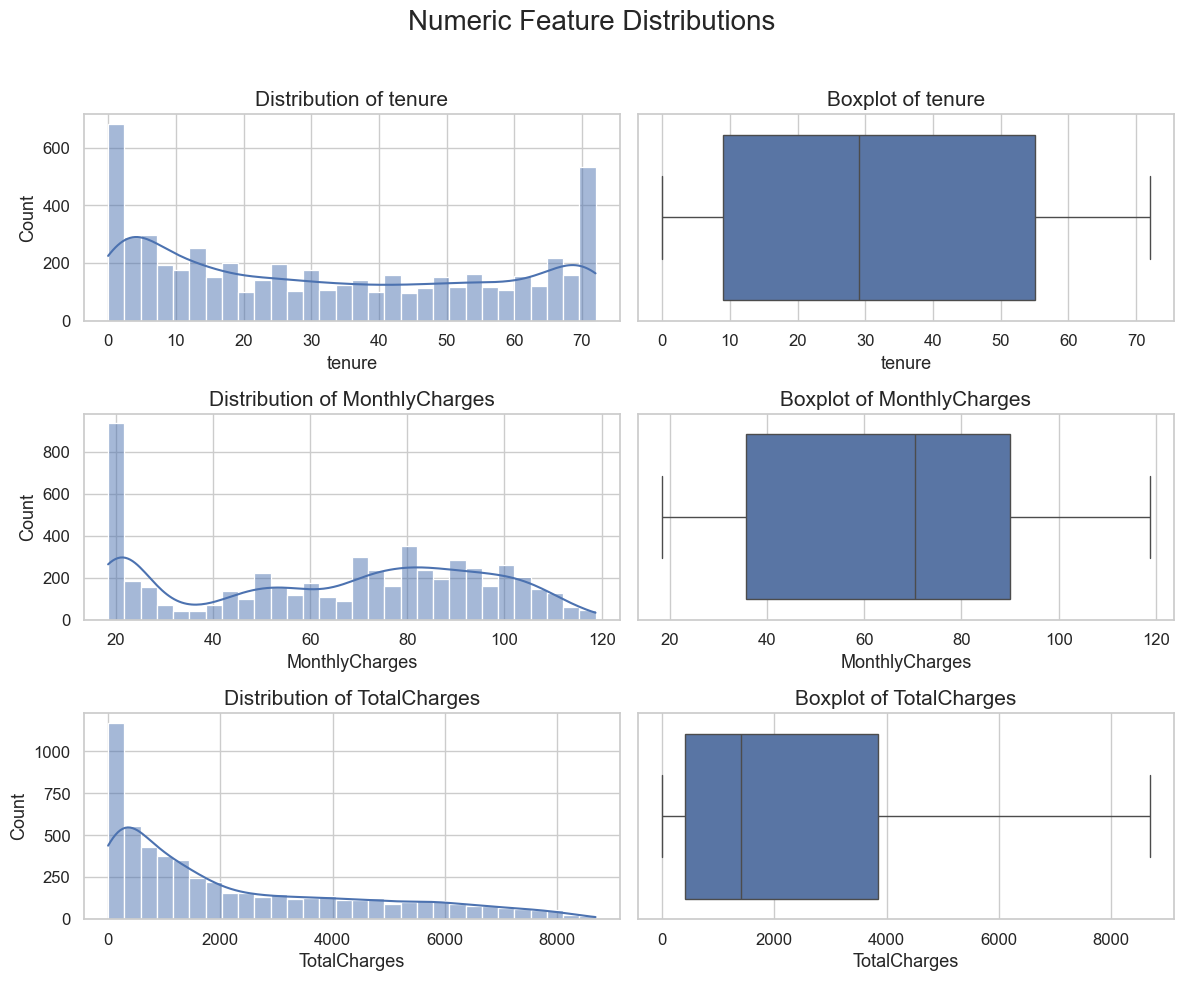

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_numeric_feature_distributions.png')

In [16]:
n_numeric = len(numeric_features)

fig, axes = plt.subplots(
    nrows=n_numeric,
    ncols=2,
    figsize=(12, 3.2 * n_numeric),
)

if n_numeric == 1:
    axes = np.array([axes])

for row_index, column in enumerate(numeric_features):
    hist_ax = axes[row_index, 0]
    box_ax = axes[row_index, 1]

    sns.histplot(
        data=train_df,
        x=column,
        bins=30,
        kde=True,
        ax=hist_ax,
    )
    hist_ax.set_title(f"Distribution of {column}")
    hist_ax.set_xlabel(column)
    hist_ax.set_ylabel("Count")
    apply_report_axis_style(hist_ax)

    sns.boxplot(
        data=train_df,
        x=column,
        ax=box_ax,
    )
    box_ax.set_title(f"Boxplot of {column}")
    box_ax.set_xlabel(column)
    apply_report_axis_style(box_ax)

fig.suptitle("Numeric Feature Distributions", fontsize=FIGURE_TITLE_SIZE, y=1.02)
fig.tight_layout()

numeric_distribution_path = FIGURES_DIR / "training_numeric_feature_distributions.png"
fig.savefig(numeric_distribution_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_distribution_path

## Numeric feature distributions by churn

These plots compare each numeric feature between churners and non-churners.
They help inspect whether the numeric feature distributions differ between the
two classes.

Because this analysis uses the target, it is performed on the training set
only.

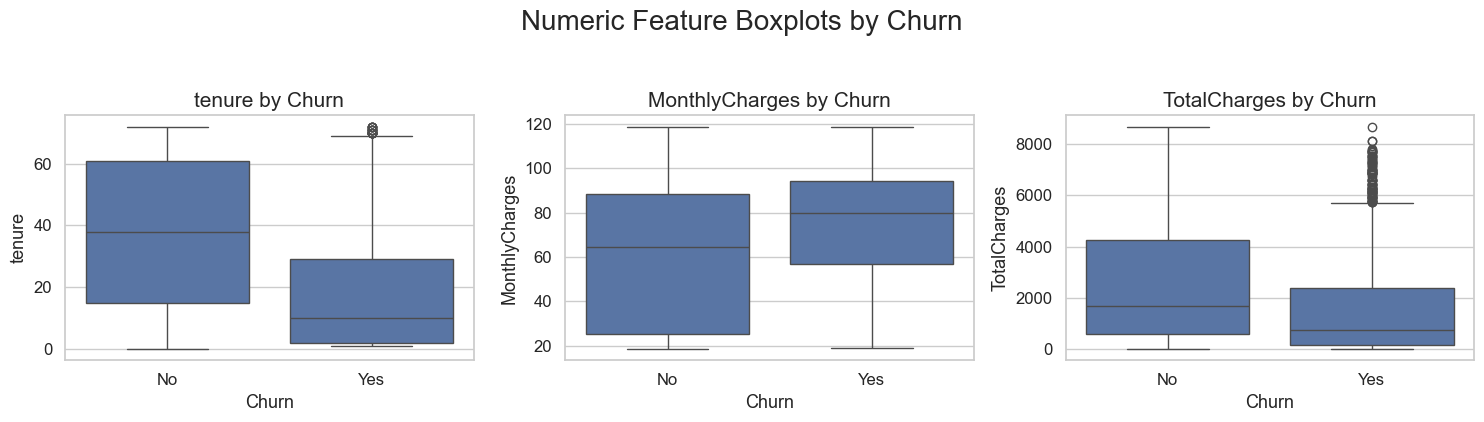

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_numeric_feature_boxplots_by_churn.png')

In [17]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numeric_features),
    figsize=(5 * len(numeric_features), 4),
)

if len(numeric_features) == 1:
    axes = [axes]

for ax, column in zip(axes, numeric_features):
    sns.boxplot(
        data=train_df,
        x=TARGET_LABEL_COLUMN,
        y=column,
        ax=ax,
    )

    ax.set_title(f"{column} by Churn")
    ax.set_xlabel("Churn")
    ax.set_ylabel(column)
    apply_report_axis_style(ax)

fig.suptitle("Numeric Feature Boxplots by Churn", fontsize=FIGURE_TITLE_SIZE, y=1.05)
fig.tight_layout()

numeric_by_churn_boxplot_path = (
    FIGURES_DIR / "training_numeric_feature_boxplots_by_churn.png"
)
fig.savefig(numeric_by_churn_boxplot_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_by_churn_boxplot_path

## Numeric scatter matrix by churn

A scatter matrix is useful for inspecting pairwise relationships among numeric
features. This dataset has only three numeric features, so the scatter matrix
is compact.

This figure is included as a visual diagnostic, not as a feature-selection
method.

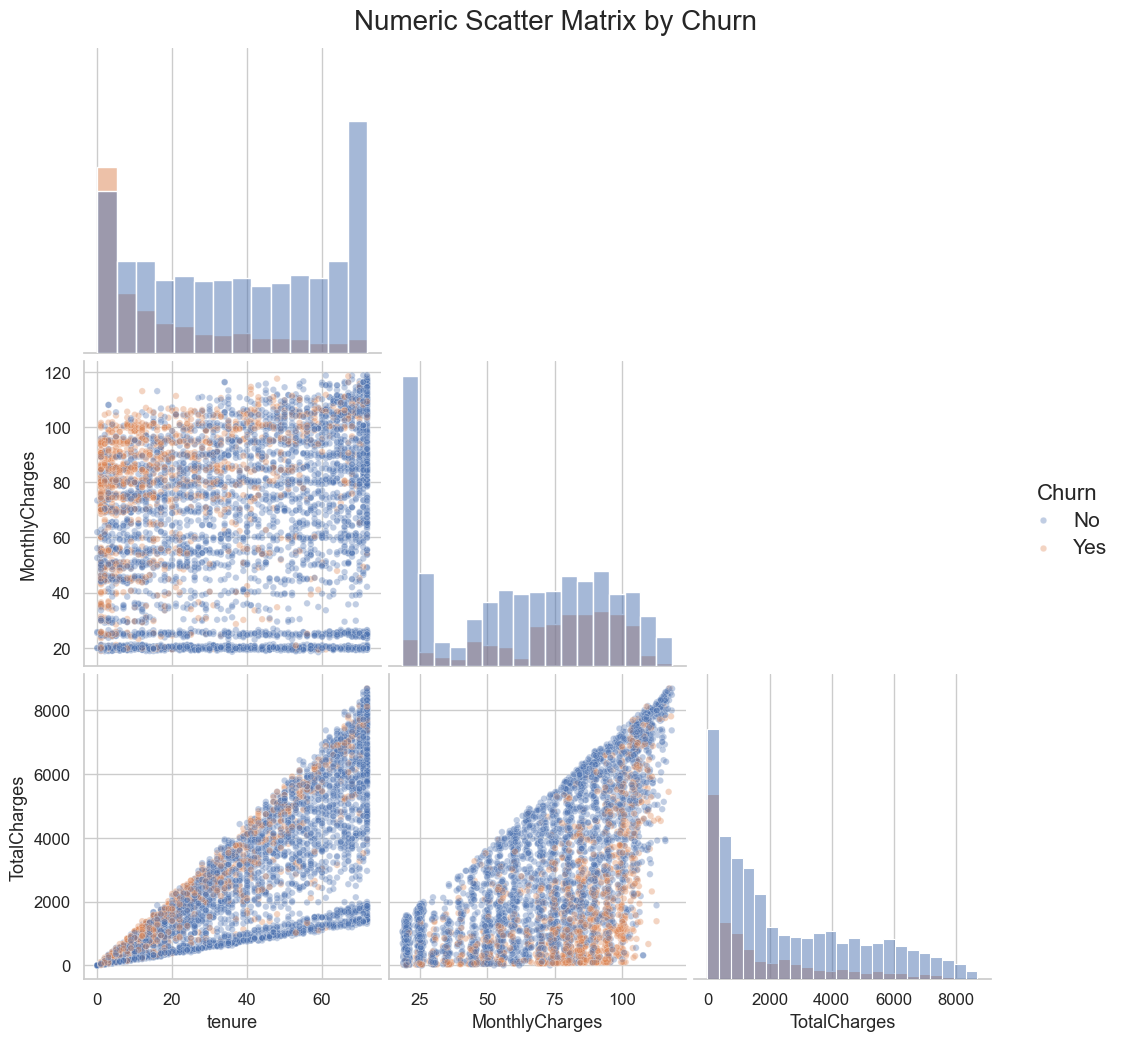

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_numeric_scatter_matrix_by_churn.png')

In [18]:
scatter_matrix_data = train_df[numeric_features + [TARGET_LABEL_COLUMN]].copy()

pair_grid = sns.pairplot(
    data=scatter_matrix_data,
    vars=numeric_features,
    hue=TARGET_LABEL_COLUMN,
    corner=True,
    diag_kind="hist",
    height=3.4,
    plot_kws={"alpha": 0.35, "s": 22},
)

pair_grid.fig.suptitle(
    "Numeric Scatter Matrix by Churn",
    y=1.02,
    fontsize=FIGURE_TITLE_SIZE,
)

for ax in pair_grid.axes.flatten():
    if ax is not None:
        apply_report_axis_style(ax)

if pair_grid._legend is not None:
    pair_grid._legend.set_title("Churn")
    pair_grid._legend.get_title().set_fontsize(16)
    for text_label in pair_grid._legend.texts:
        text_label.set_fontsize(15)

numeric_scatter_matrix_path = (
    FIGURES_DIR / "training_numeric_scatter_matrix_by_churn.png"
)
pair_grid.fig.savefig(numeric_scatter_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_scatter_matrix_path

### Interpretation

The scatter matrix shows visible churn-related patterns, but it does not show
a clean visual separation between churners and non-churners using any single
pair of numeric variables. Churners are more concentrated among customers
with shorter tenure and are also relatively visible among customers with
higher monthly charges. However, the two classes overlap substantially across
the numeric feature space, so churn is not separable by a simple pairwise
numeric boundary.

The clearest structural pattern is the relationship between `tenure` and
`TotalCharges`. The triangular shape is expected because total charges
accumulate over months and are also affected by monthly charges. For a fixed
tenure, customers with higher monthly charges can accumulate higher total
charges.

This motivates using models that can combine numeric and categorical
information, and potentially models that can learn interactions.

## Numeric correlation matrix including the target

The correlation matrix gives a compact overview of linear association among
the numeric features and the binary target.

Correlation is not a full feature-importance method. It does not capture
nonlinear relationships, interactions, or categorical effects.

In [19]:
numeric_correlation_columns = numeric_features + [BINARY_TARGET_COLUMN]

numeric_correlation_matrix = train_df[numeric_correlation_columns].corr()

numeric_correlation_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_binary
tenure,1.0000,0.2567,0.8297,-0.3456
MonthlyCharges,0.2567,1.0000,0.6541,0.1980
TotalCharges,0.8297,0.6541,1.0000,-0.1938
Churn_binary,-0.3456,0.1980,-0.1938,1.0000


In [20]:
numeric_correlation_path_csv = TABLES_DIR / "training_numeric_correlation_matrix.csv"
numeric_correlation_matrix.to_csv(numeric_correlation_path_csv)

numeric_correlation_path_csv

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/tables/training_numeric_correlation_matrix.csv')

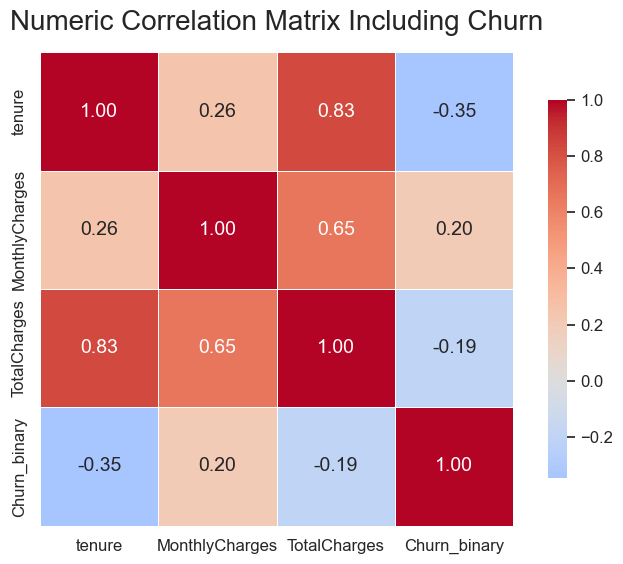

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_numeric_correlation_matrix.png')

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 5.8))

sns.heatmap(
    numeric_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": HEATMAP_ANNOTATION_SIZE},
    ax=ax,
)

ax.set_title(
    "Numeric Correlation Matrix Including Churn",
    fontsize=FIGURE_TITLE_SIZE,
    pad=16,
)
apply_report_axis_style(ax, title_size=FIGURE_TITLE_SIZE)
if ax.collections and ax.collections[0].colorbar is not None:
    ax.collections[0].colorbar.ax.tick_params(labelsize=TICK_LABEL_SIZE)
fig.tight_layout()

numeric_correlation_path = (
    FIGURES_DIR / "training_numeric_correlation_matrix.png"
)
fig.savefig(numeric_correlation_path, dpi=300, bbox_inches="tight")

plt.show()

numeric_correlation_path

## Categorical feature frequency summary

This table summarizes the number of levels and most common level for each
categorical feature in the training set.

In [22]:
categorical_frequency_summary_rows = []

for column in categorical_features:
    counts = train_df[column].value_counts(dropna=False)
    percentages = 100 * train_df[column].value_counts(normalize=True, dropna=False)

    categorical_frequency_summary_rows.append(
        {
            "feature": column,
            "number_of_levels": counts.shape[0],
            "most_common_level": str(counts.index[0]),
            "most_common_count": int(counts.iloc[0]),
            "most_common_percentage": percentages.iloc[0],
            "least_common_level": str(counts.index[-1]),
            "least_common_count": int(counts.iloc[-1]),
            "least_common_percentage": percentages.iloc[-1],
        }
    )

categorical_frequency_summary = pd.DataFrame(
    categorical_frequency_summary_rows
).sort_values(
    ["number_of_levels", "feature"],
    ascending=[False, True],
).reset_index(drop=True)

categorical_frequency_summary

,feature,number_of_levels,most_common_level,most_common_count,most_common_percentage,least_common_level,least_common_count,least_common_percentage
0,PaymentMethod,4,Electronic check,1891,33.5641,Credit card (automatic),1213,21.5300
1,Contract,3,Month-to-month,3102,55.0586,One year,1173,20.8200
2,DeviceProtection,3,No,2472,43.8765,No internet service,1214,21.5477
3,InternetService,3,Fiber optic,2483,44.0717,No,1214,21.5477
4,MultipleLines,3,No,2685,47.6571,No phone service,559,9.9219
5,OnlineBackup,3,No,2442,43.3440,No internet service,1214,21.5477
6,OnlineSecurity,3,No,2797,49.6450,No internet service,1214,21.5477
7,StreamingMovies,3,No,2217,39.3504,No internet service,1214,21.5477
8,StreamingTV,3,No,2226,39.5101,No internet service,1214,21.5477
9,TechSupport,3,No,2771,49.1835,No internet service,1214,21.5477


In [23]:
categorical_frequency_summary_path = (
    TABLES_DIR / "training_categorical_frequency_summary.csv"
)
categorical_frequency_summary.to_csv(categorical_frequency_summary_path, index=False)

categorical_frequency_summary_path

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/tables/training_categorical_frequency_summary.csv')

## Categorical feature frequency plots

The frequency plots show how common each category level is in the training
data. These plots answer a different question from churn-rate plots.

- Frequency plot: how common is this level?
- Churn-rate plot: how often does churn occur within this level?

Because the project contains many categorical variables, the plots are split
into two report-ready figures. This keeps axis labels and category labels
readable in the PDF report while preserving the same analysis.

In [24]:
def plot_categorical_frequency_grid(
    features: list[str],
    output_path: Path,
    suptitle: str,
) -> None:
    """Plot categorical level frequencies for a subset of categorical features.

    The full categorical feature set is intentionally split across multiple
    figures. A single grid with all categorical variables is useful inside a
    notebook but becomes too compressed once inserted into the LaTeX report.
    Splitting the figure improves readability without changing the underlying
    analysis.
    """
    n_features = len(features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(16, 4.6 * n_rows),
    )

    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, features):
        frequency_table = (
            train_df[column]
            .value_counts(normalize=True, dropna=False)
            .mul(100)
            .rename("percentage")
            .reset_index()
        )

        frequency_table.columns = ["level", "percentage"]
        frequency_table["level"] = frequency_table["level"].astype(str)

        sns.barplot(
            data=frequency_table,
            x="percentage",
            y="level",
            ax=ax,
        )

        ax.set_title(column, fontsize=SUBPLOT_TITLE_SIZE)
        ax.set_xlabel("Percentage", fontsize=AXIS_LABEL_SIZE)
        ax.set_ylabel("")
        ax.set_xlim(0, 100)
        apply_report_axis_style(ax)

    for unused_ax in axes[n_features:]:
        unused_ax.remove()

    fig.suptitle(suptitle, fontsize=FIGURE_TITLE_SIZE, y=1.01)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

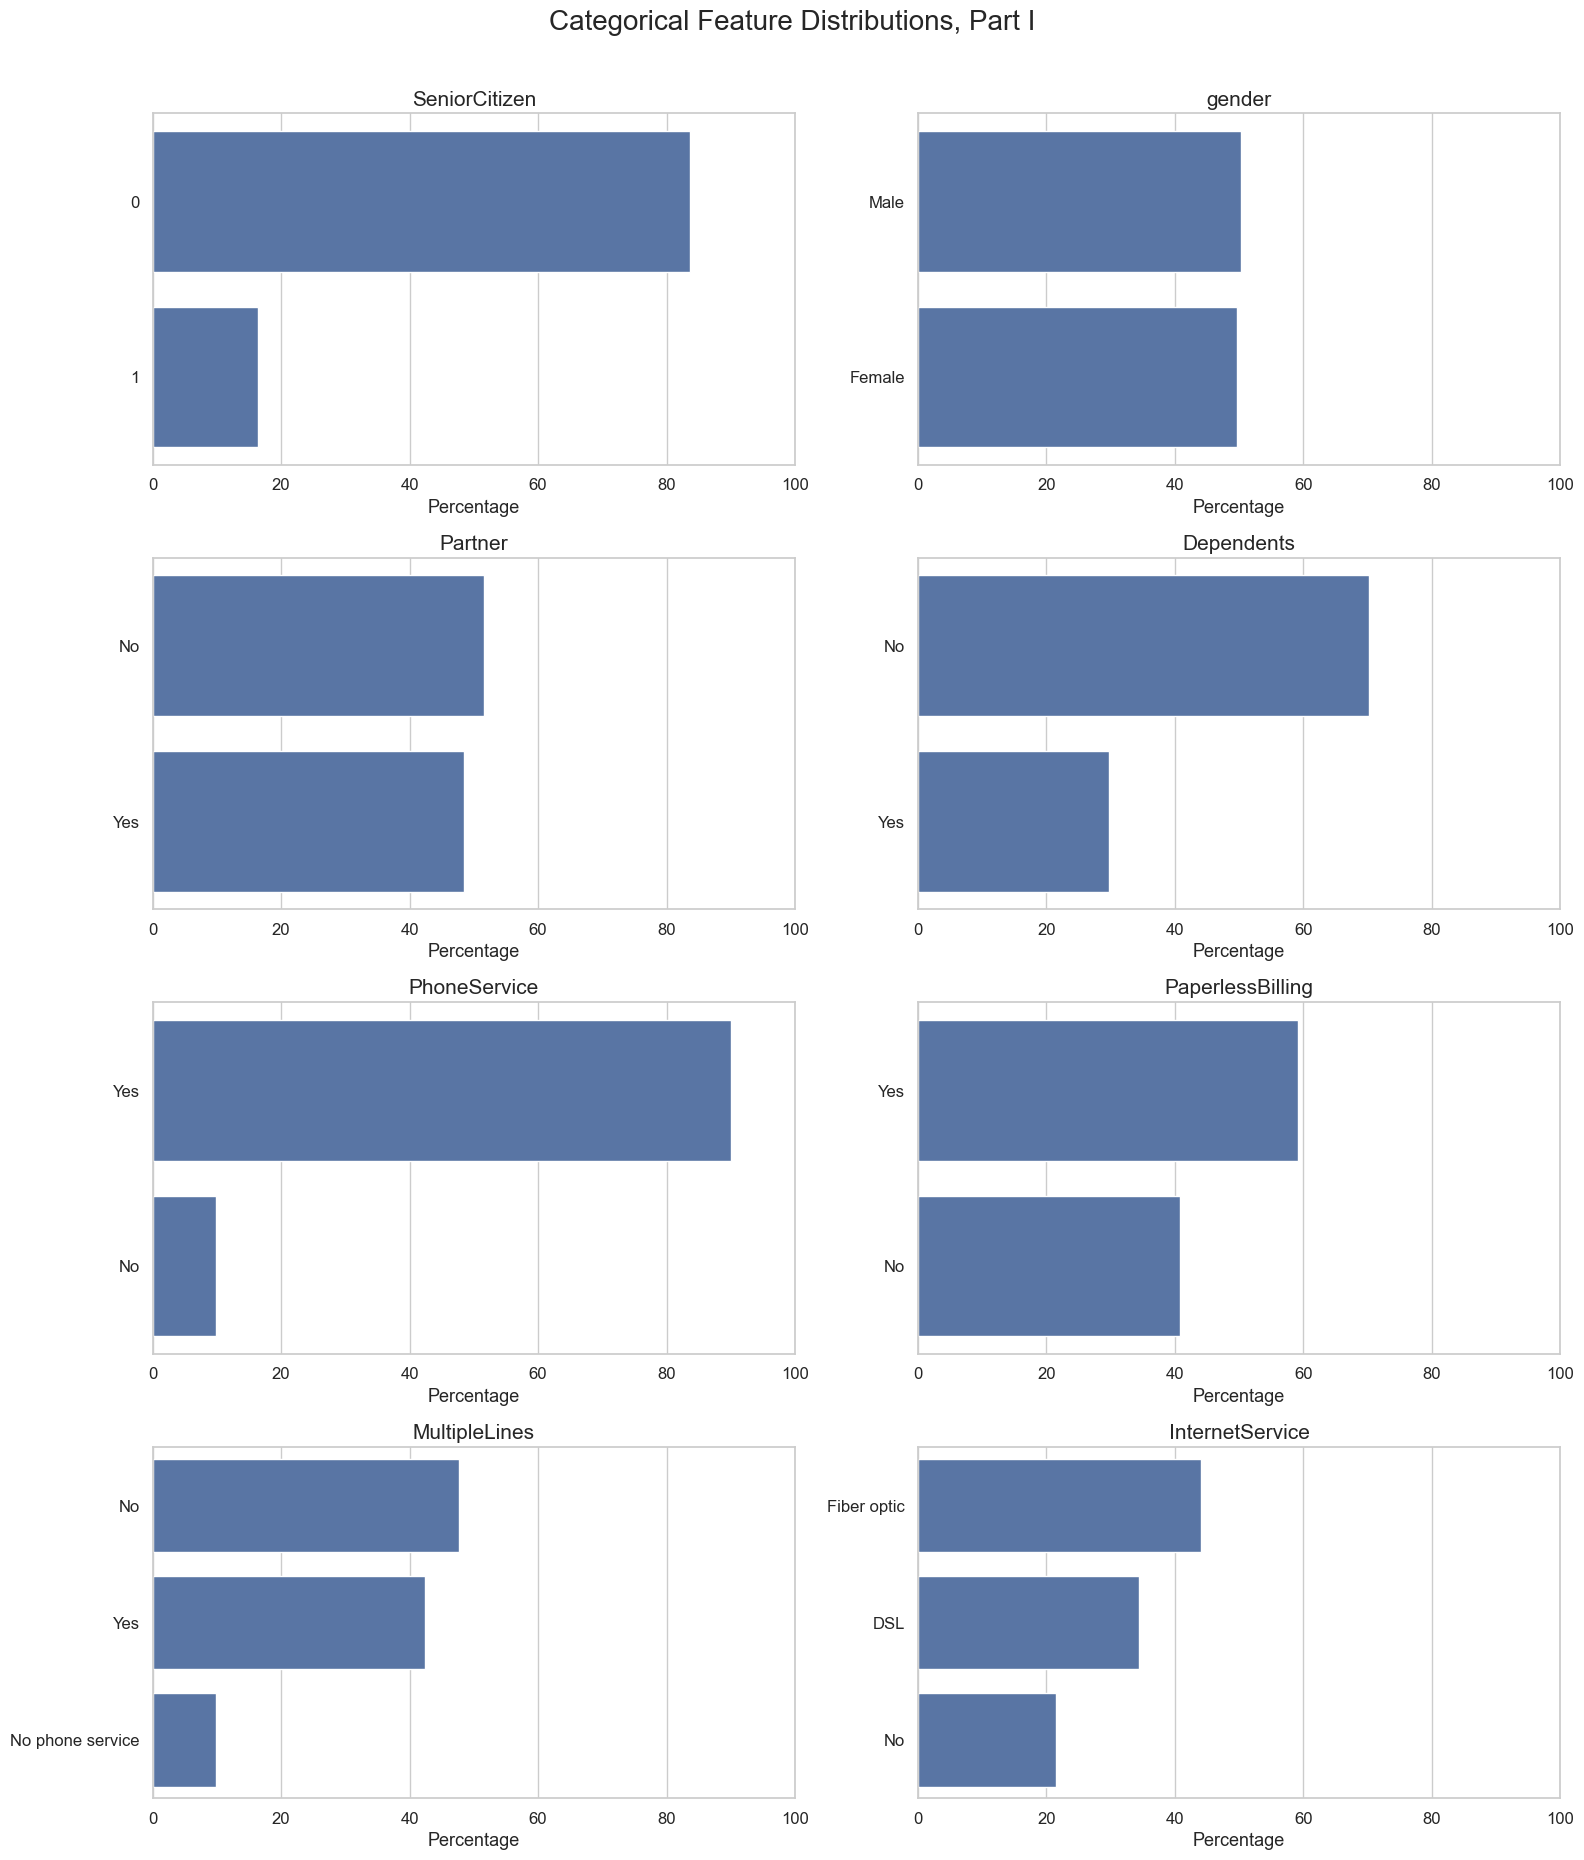

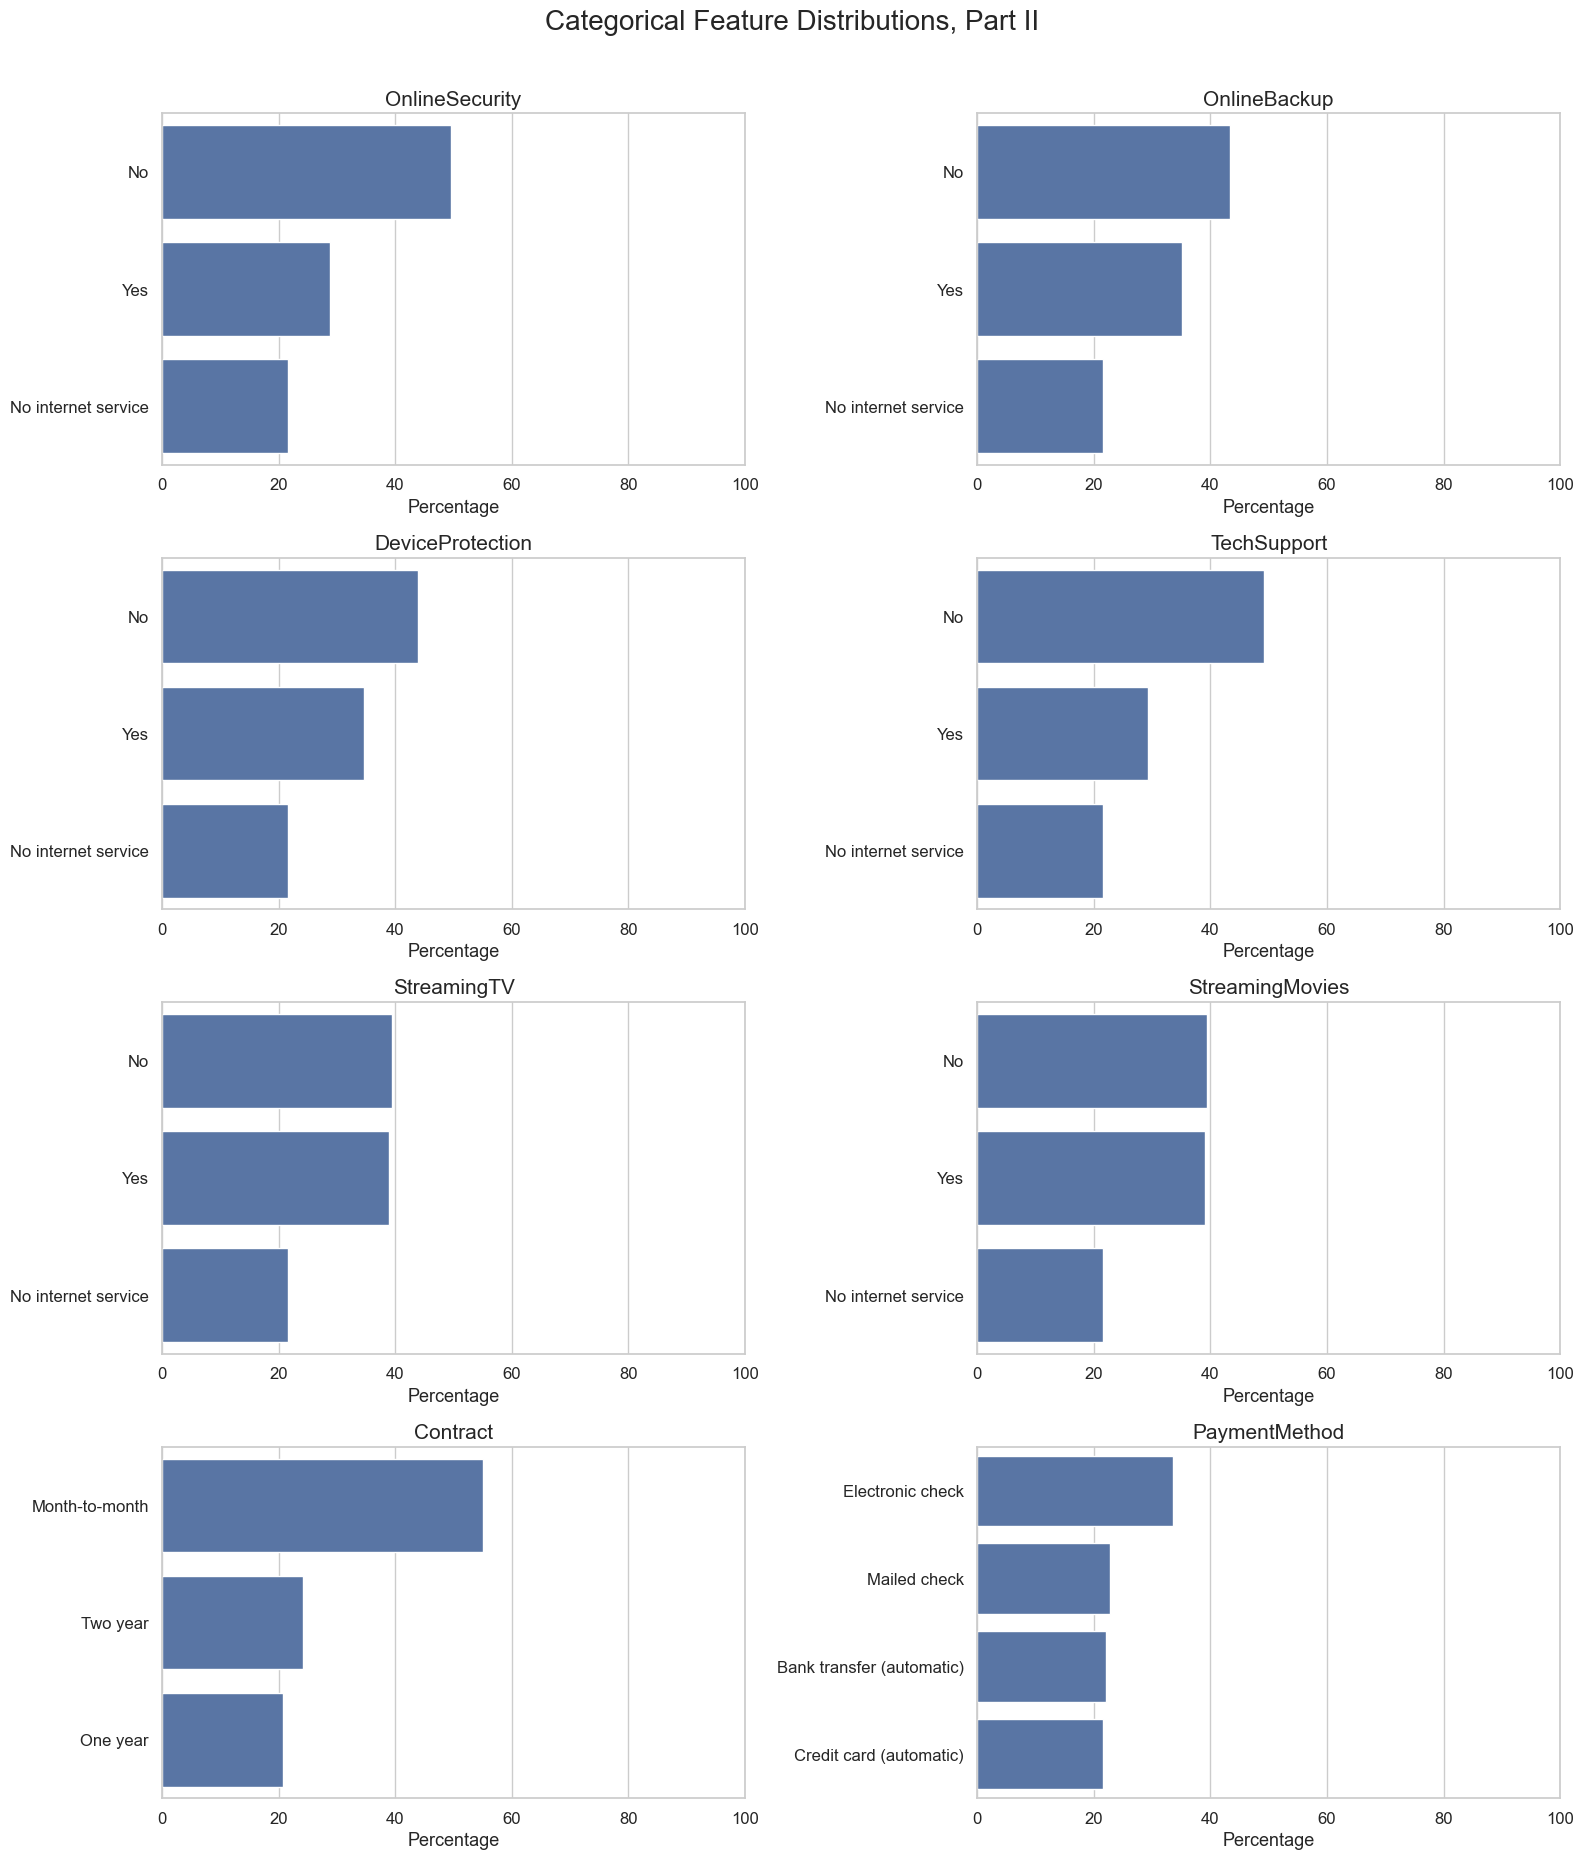

[WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_categorical_feature_frequencies_part_1.png'),
 WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_categorical_feature_frequencies_part_2.png')]

In [25]:
categorical_frequency_path_part_1 = (
    FIGURES_DIR / "training_categorical_feature_frequencies_part_1.png"
)
categorical_frequency_path_part_2 = (
    FIGURES_DIR / "training_categorical_feature_frequencies_part_2.png"
)

plot_categorical_frequency_grid(
    categorical_features_part_1,
    categorical_frequency_path_part_1,
    "Categorical Feature Distributions, Part I",
)

plot_categorical_frequency_grid(
    categorical_features_part_2,
    categorical_frequency_path_part_2,
    "Categorical Feature Distributions, Part II",
)

[
    categorical_frequency_path_part_1,
    categorical_frequency_path_part_2,
]

### Interpretation

The frequency plots make the category balance easier to compare across
features. They are split into two figures only for readability. Together,
they show that the dataset is mainly composed of customers with phone
service, non-senior customers, and many month-to-month contracts. They also
show that several internet-service add-on variables share the same structural
`No internet service` group.

These frequency plots answer how common each level is. They should be
interpreted together with the churn-rate plots, which answer how often churn
occurs inside each level.

## Categorical churn-rate summary

The churn-rate table summarizes, for each categorical feature level:

- how many training observations are in the level;
- how common the level is in the training set;
- how many churn cases occur in the level;
- the churn percentage within the level.

This is target-based EDA and therefore uses training data only.

In [26]:
categorical_churn_tables = []

for column in categorical_features:
    table = (
        train_df.groupby(column, dropna=False)
        .agg(
            count=(BINARY_TARGET_COLUMN, "size"),
            churn_count=(BINARY_TARGET_COLUMN, "sum"),
        )
        .reset_index()
        .rename(columns={column: "level"})
    )

    table["level"] = table["level"].astype(str)

    table.insert(0, "feature", column)
    table["training_percentage"] = 100 * table["count"] / len(train_df)
    table["churn_percentage"] = 100 * table["churn_count"] / table["count"]

    categorical_churn_tables.append(table)

categorical_churn_summary = pd.concat(
    categorical_churn_tables,
    ignore_index=True,
)

categorical_churn_summary = categorical_churn_summary[
    [
        "feature",
        "level",
        "count",
        "training_percentage",
        "churn_count",
        "churn_percentage",
    ]
].sort_values(
    ["feature", "churn_percentage"],
    ascending=[True, False],
).reset_index(drop=True)

categorical_churn_summary

,feature,level,count,training_percentage,churn_count,churn_percentage
0,Contract,Month-to-month,3102,55.0586,1326,42.7466
1,Contract,One year,1173,20.8200,130,11.0827
2,Contract,Two year,1359,24.1214,39,2.8698
3,Dependents,No,3955,70.1988,1240,31.3527
4,Dependents,Yes,1679,29.8012,255,15.1876
5,DeviceProtection,No,2472,43.8765,963,38.9563
6,DeviceProtection,Yes,1948,34.5758,444,22.7926
7,DeviceProtection,No internet service,1214,21.5477,88,7.2488
8,InternetService,Fiber optic,2483,44.0717,1045,42.0862
9,InternetService,DSL,1937,34.3805,362,18.6887


In [27]:
categorical_churn_summary_path = TABLES_DIR / "training_categorical_churn_summary.csv"
categorical_churn_summary.to_csv(categorical_churn_summary_path, index=False)

categorical_churn_summary_path

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/tables/training_categorical_churn_summary.csv')

## Categorical churn-rate plots

The churn-rate plots visualize the target rate inside each category level.
They are useful for interpretation and for motivating simple rule-based
baselines later, but they are not themselves final models.

As with the frequency plots, the churn-rate plots are split into two
report-ready figures to avoid unreadably small labels in the PDF report.

In [28]:
def plot_categorical_churn_grid(
    features: list[str],
    output_path: Path,
    suptitle: str,
) -> None:
    """Plot churn percentages for a subset of categorical features.

    Each subplot shows the churn percentage conditional on a category level.
    These are marginal training associations, not causal effects. The visual
    split into two figures is purely a presentation choice for report
    readability.
    """
    n_features = len(features)
    n_cols = 2
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(16, 4.6 * n_rows),
    )

    axes = np.array(axes).reshape(-1)

    for ax, column in zip(axes, features):
        plot_table = categorical_churn_summary.loc[
            categorical_churn_summary["feature"] == column,
            ["level", "count", "churn_percentage"],
        ].copy()

        plot_table["level"] = plot_table["level"].astype(str)
        plot_table = plot_table.sort_values(
            "churn_percentage",
            ascending=False,
        )

        sns.barplot(
            data=plot_table,
            x="churn_percentage",
            y="level",
            ax=ax,
        )

        ax.set_title(column, fontsize=SUBPLOT_TITLE_SIZE)
        ax.set_xlabel("Churn percentage", fontsize=AXIS_LABEL_SIZE)
        ax.set_ylabel("")
        ax.set_xlim(0, 100)
        apply_report_axis_style(ax)

    for unused_ax in axes[n_features:]:
        unused_ax.remove()

    fig.suptitle(suptitle, fontsize=FIGURE_TITLE_SIZE, y=1.01)
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

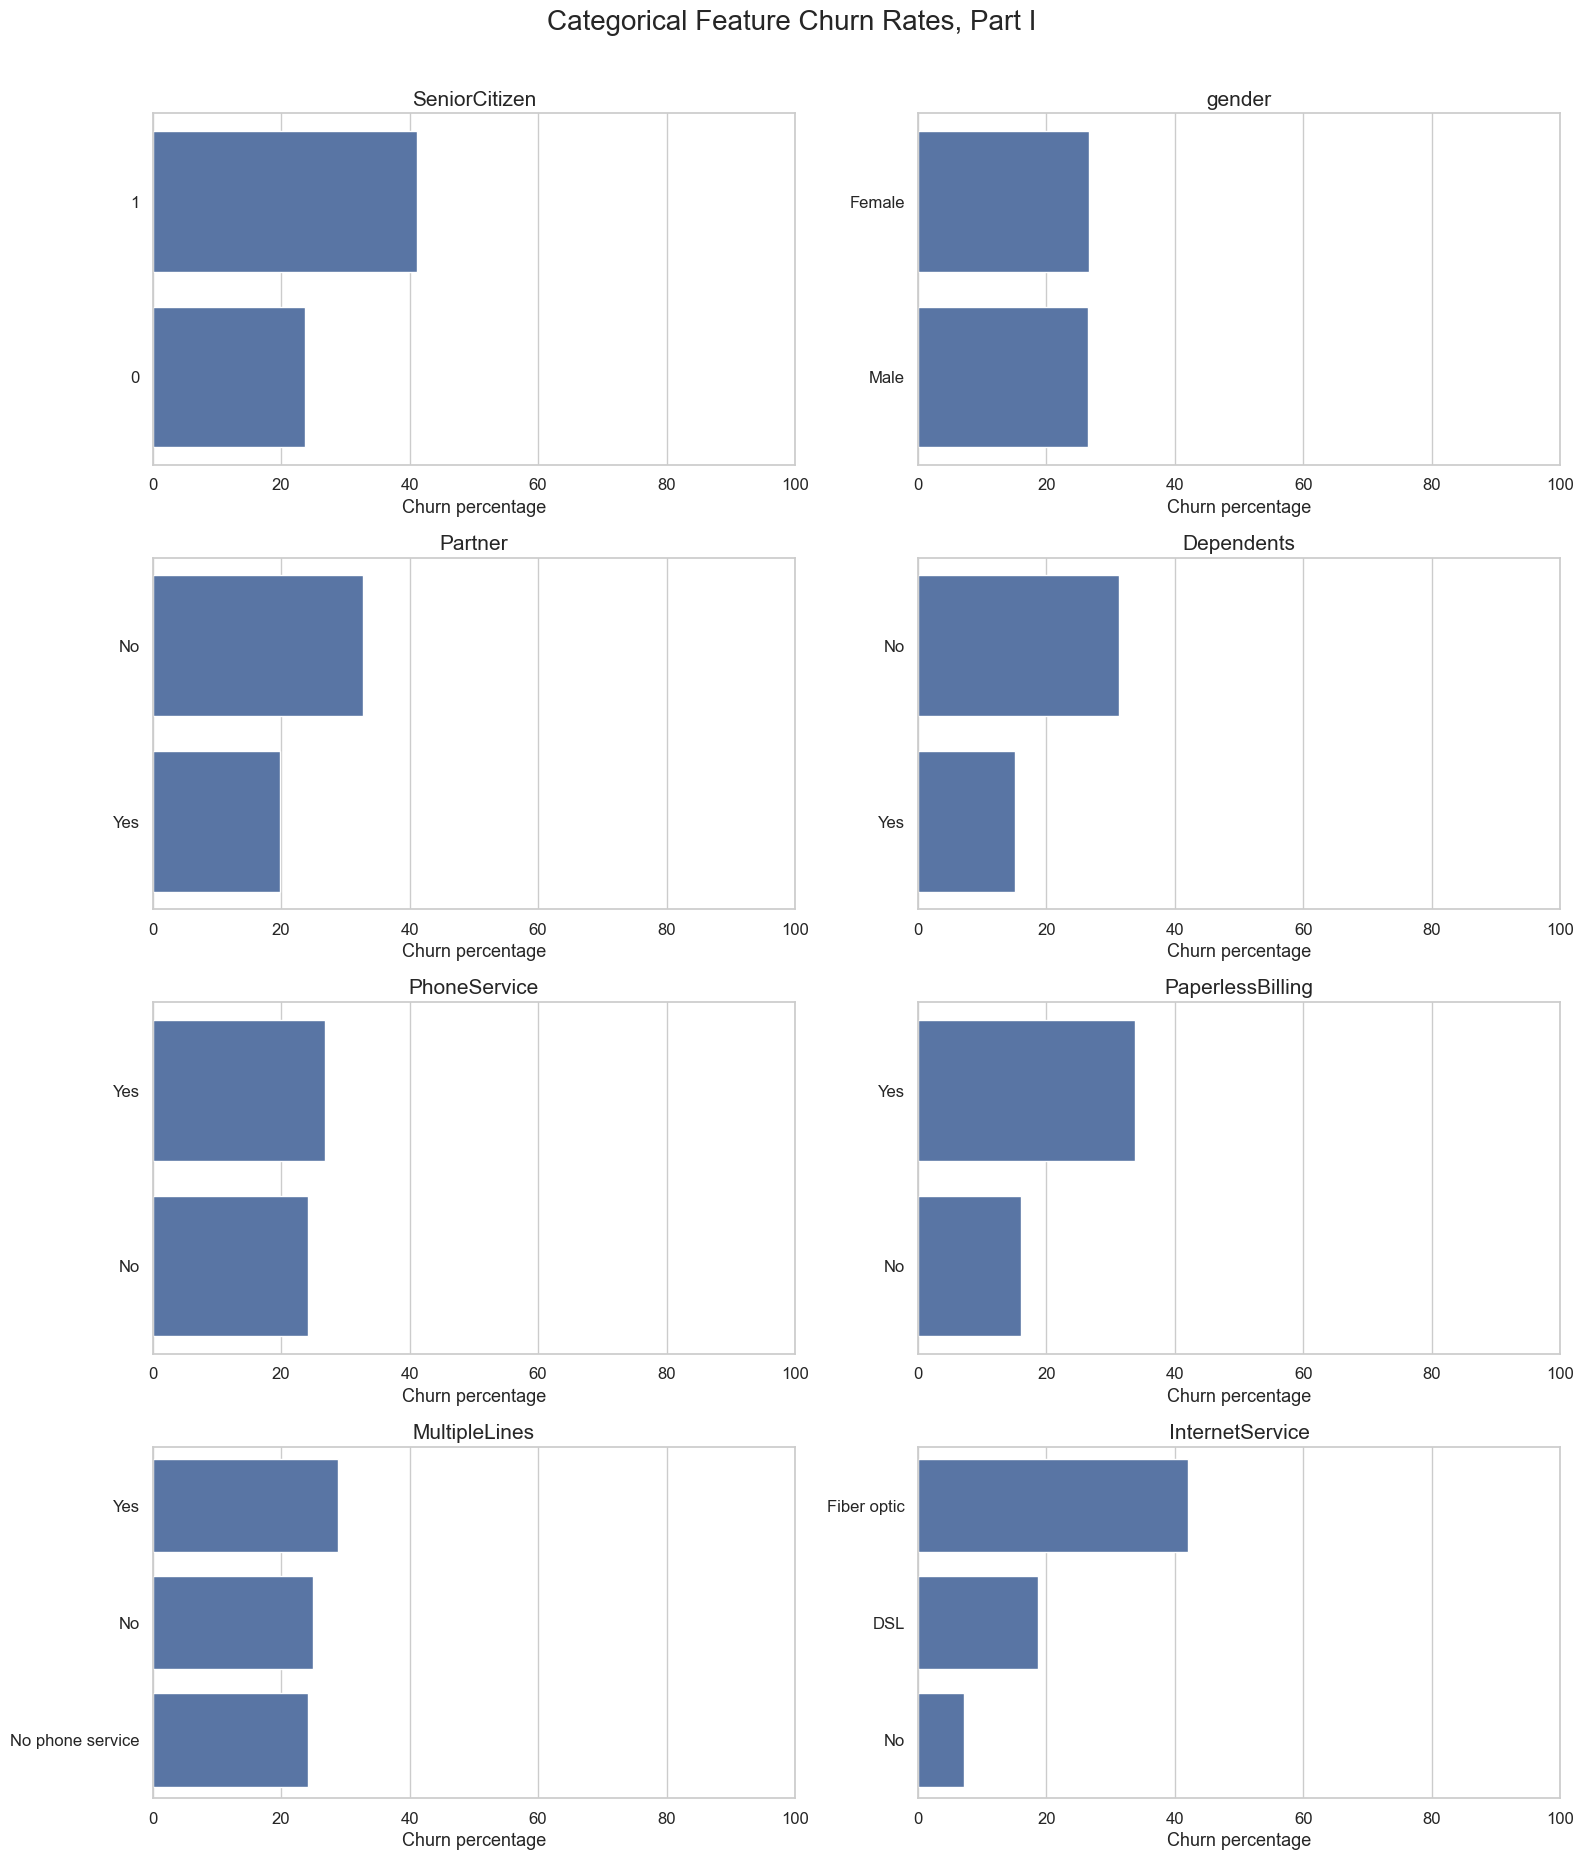

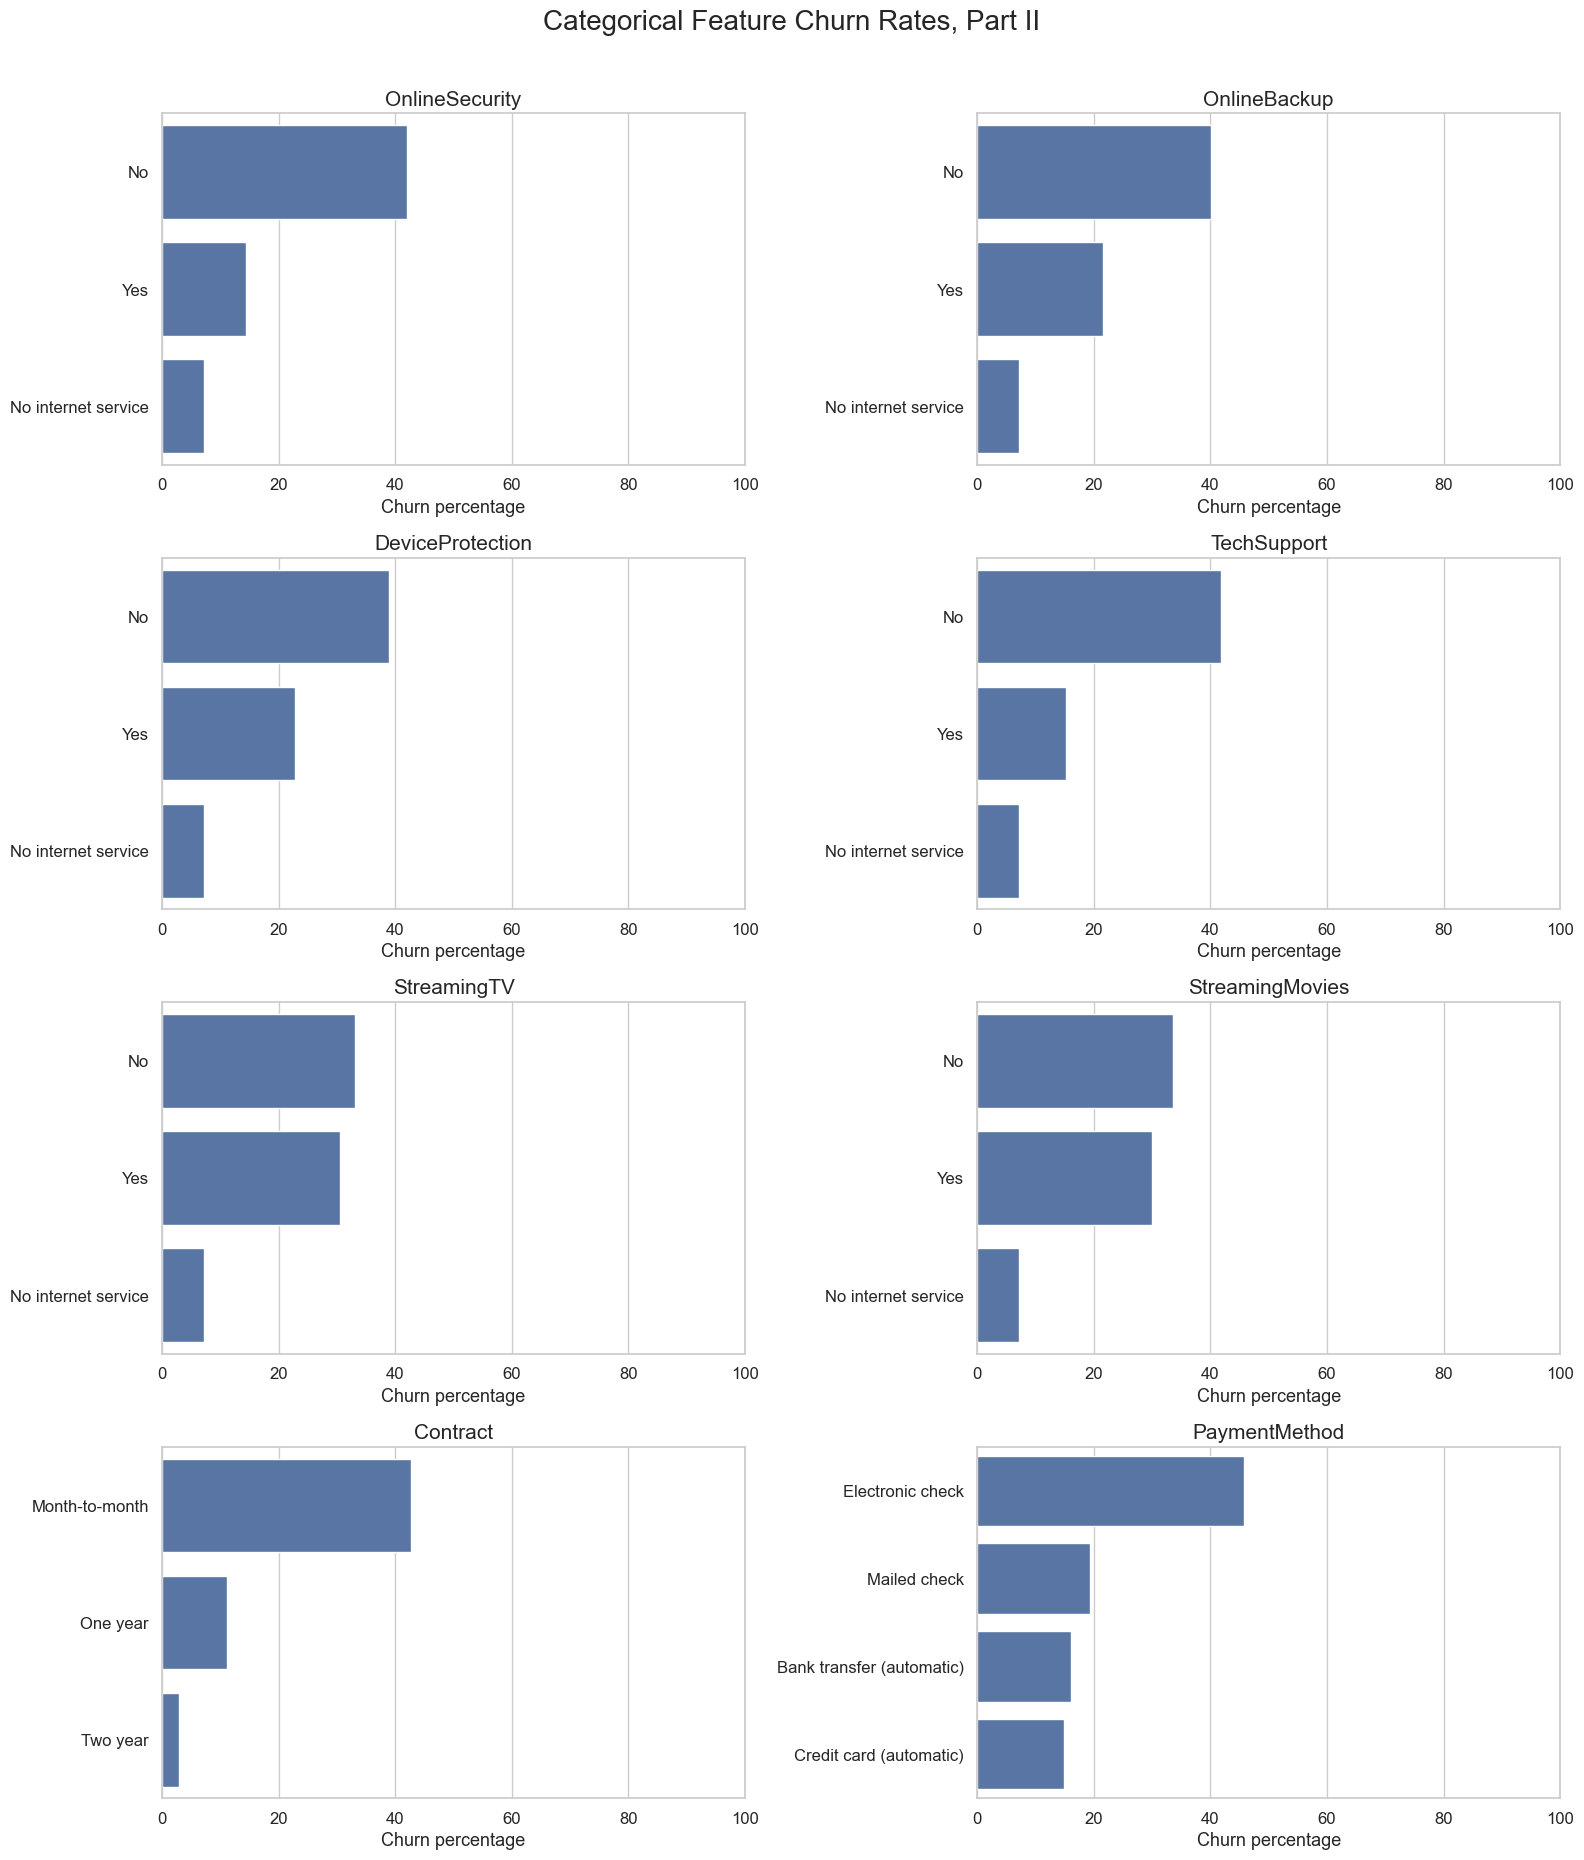

[WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_categorical_feature_churn_rates_part_1.png'),
 WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/figures/training_categorical_feature_churn_rates_part_2.png')]

In [29]:
categorical_churn_rate_path_part_1 = (
    FIGURES_DIR / "training_categorical_feature_churn_rates_part_1.png"
)
categorical_churn_rate_path_part_2 = (
    FIGURES_DIR / "training_categorical_feature_churn_rates_part_2.png"
)

plot_categorical_churn_grid(
    categorical_features_part_1,
    categorical_churn_rate_path_part_1,
    "Categorical Feature Churn Rates, Part I",
)

plot_categorical_churn_grid(
    categorical_features_part_2,
    categorical_churn_rate_path_part_2,
    "Categorical Feature Churn Rates, Part II",
)

[
    categorical_churn_rate_path_part_1,
    categorical_churn_rate_path_part_2,
]

### Interpretation

The churn-rate plot grids visualize the same training associations as the
churn-rate table. They are split into two figures only for readability.

The largest visible contrasts occur for `Contract`, `PaymentMethod`,
`InternetService`, `OnlineSecurity`, `TechSupport`, `OnlineBackup`,
`DeviceProtection`, `PaperlessBilling`, and `SeniorCitizen`.

The plots also show that some features have little marginal separation. For
example, churn rates for `gender` are almost identical, and `PhoneService`
shows only a small difference. This does not mean those variables must be
removed, because they may still contribute through interactions or in
combination with other features, but it suggests that their standalone
marginal relationship with churn is weak.

These are associations in the training data. They should not be interpreted
as causal effects.

## Selected categorical churn-rate table

The full churn-rate table is saved as a CSV. A smaller selected table is also
created for the LaTeX report.

In [30]:
selected_feature_levels = [
    ("Contract", "Month-to-month"),
    ("Contract", "One year"),
    ("Contract", "Two year"),
    ("InternetService", "Fiber optic"),
    ("InternetService", "DSL"),
    ("InternetService", "No"),
    ("PaymentMethod", "Electronic check"),
    ("PaperlessBilling", "Yes"),
    ("PaperlessBilling", "No"),
    ("SeniorCitizen", "1"),
    ("SeniorCitizen", "0"),
]

selected_rows = []

for feature, level in selected_feature_levels:
    matching_rows = categorical_churn_summary.loc[
        (categorical_churn_summary["feature"] == feature)
        & (categorical_churn_summary["level"] == level)
    ]

    if not matching_rows.empty:
        selected_rows.append(matching_rows.iloc[0])

selected_categorical_churn_summary = pd.DataFrame(selected_rows).reset_index(drop=True)

selected_categorical_churn_summary

,feature,level,count,training_percentage,churn_count,churn_percentage
0,Contract,Month-to-month,3102,55.0586,1326,42.7466
1,Contract,One year,1173,20.8200,130,11.0827
2,Contract,Two year,1359,24.1214,39,2.8698
3,InternetService,Fiber optic,2483,44.0717,1045,42.0862
4,InternetService,DSL,1937,34.3805,362,18.6887
5,InternetService,No,1214,21.5477,88,7.2488
6,PaymentMethod,Electronic check,1891,33.5641,865,45.7430
7,PaperlessBilling,Yes,3331,59.1232,1126,33.8037
8,PaperlessBilling,No,2303,40.8768,369,16.0226
9,SeniorCitizen,1,920,16.3294,378,41.0870


In [31]:
selected_categorical_churn_summary_path = (
    TABLES_DIR / "training_selected_categorical_churn_summary.csv"
)
selected_categorical_churn_summary.to_csv(
    selected_categorical_churn_summary_path,
    index=False,
)

selected_categorical_churn_summary_path

WindowsPath('C:/Projects_Data/classification/telco-customer-churn-classification/reports/tables/training_selected_categorical_churn_summary.csv')

## Summary of generated outputs

The saved figures and tables from this notebook are used by the LaTeX report.
The next workflow stage will use the training set to build preprocessing
pipelines and baseline models.

In [32]:
generated_outputs = pd.DataFrame(
    {
        "output_type": [
            "table",
            "figure",
            "figure",
            "figure",
            "table",
            "figure",
            "table",
            "figure",
            "figure",
            "table",
            "figure",
            "figure",
            "table",
        ],
        "path": [
            numeric_summary_path,
            numeric_distribution_path,
            numeric_by_churn_boxplot_path,
            numeric_scatter_matrix_path,
            numeric_correlation_path_csv,
            numeric_correlation_path,
            categorical_frequency_summary_path,
            categorical_frequency_path_part_1,
            categorical_frequency_path_part_2,
            categorical_churn_summary_path,
            categorical_churn_rate_path_part_1,
            categorical_churn_rate_path_part_2,
            selected_categorical_churn_summary_path,
        ],
    }
)

generated_outputs

,output_type,path
0,table,C:\Projects_Data\classification\telco-customer...
1,figure,C:\Projects_Data\classification\telco-customer...
2,figure,C:\Projects_Data\classification\telco-customer...
3,figure,C:\Projects_Data\classification\telco-customer...
4,table,C:\Projects_Data\classification\telco-customer...
5,figure,C:\Projects_Data\classification\telco-customer...
6,table,C:\Projects_Data\classification\telco-customer...
7,figure,C:\Projects_Data\classification\telco-customer...
8,figure,C:\Projects_Data\classification\telco-customer...
9,table,C:\Projects_Data\classification\telco-customer...
